<a href="https://colab.research.google.com/github/vkawasth/Leaker/blob/main/Attention_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install & imports
# (Everything is stdlib / PyTorch / matplotlib; no internet needed in Colab.)

import math, random, time
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Pytorch dataset loader for batchmode training
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [2]:
SPLINE_ORDER = 1
class multiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(multiHeadAttention, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # KANLinear runs out of memory
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        ######### nn.Linear can be KANLinear
        #self.W_q = KANLinear(d_model, d_model)
        #self.W_k = KANLinear(d_model, d_model)
        #self.W_v = KANLinear(d_model, d_model)
        #self.W_o = KANLinear(d_model, d_model)


    def attention(self, Q, K, V, mask=None):
        attention_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            attention_score = attention_score.masked_fill( mask == 0, -1e9)

        attention_probability = torch.softmax(attention_score, dim=-1)
        output = torch.matmul(attention_probability, V)
        return output, attention_probability

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1,2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1,2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attention_output, attention = self.attention(Q,K,V, mask)

        out = self.W_o(self.combine_heads(attention_output))
        return out, attention

# ----------------------------------------------------------------------------------------------------
# Base activation is har-coded to SiLU
# https://github.com/1ssb/torchkan/blob/main/KALnet.py
# efficient_kan also used SiLU activation.
# polynomial order is starting with linear, splines (efficient_kan), Legendre polynomial (see link)
# MLP is linear-Relu(linear) KAN is f2(f1(x))...
# ----------------------------------------------------------------------------------------------------

class KANLinear(torch.nn.Module):
    def __init__(
            self,
            in_features,
            out_features,
            grid_size=3,
            spline_order=SPLINE_ORDER, # don't try cubic splines, very long training..
            scale_noise=0.1,
            scale_base=1.0,
            scale_spline=1.0,
            stand_alone_spline=True,
            base_activation=torch.nn.SiLU,
            grid_eps=0.02,
            grid_range=[-1,1],):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) /grid_size
        grid = ((torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]).expand(in_features,-1).contiguous())
        self.register_buffer("grid", grid)
        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features, grid_size+spline_order))
        if stand_alone_spline:
            self.spline_scaler = torch.nn.Parameter(torch.Tensor(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.stand_alone_spline = stand_alone_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            # set some random data
            noise = ((torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 1/2)* self.scale_noise / self.grid_size)
            self.spline_weight.data.copy_((self.scale_spline if not self.stand_alone_spline else 1.0)*
                                          self.curve2coeff(self.grid.T[self.spline_order : -self.spline_order],
                                                           noise,))
            if self.stand_alone_spline:
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a= math.sqrt(5) * self.scale_spline)
    #------------------------------------------------------------------------------------------------------------------------
    # 2d splines
    # These splines do not scale for large models.
    # some have tried Rational Base functions (F(x) = P(x)/Q(x) = {a_0 + a_1x+...a_mx(^m)}/{1 + |b_1x+b_2x^2+...b_nx^n|}
    # I am only going to try exponential function y = e^(ax), This will help me in creating exponential maps on manifolds.
    #  -- here a is the parameter learnt during training. which is really Sigma_0^n (2^n).x^n/n! for a=2.
    # I did not add any term at start i.e. f(x) = be^(ax), where b and a are parameters as then at x=0, function = 1, property
    # vanishes.
    #------------------------------------------------------------------------------------------------------------------------
    # code tailored from efficient-kan
    def b_splines(self, x: torch.Tensor):
        # generates a grid like tensor pytorch bs.
        grid: torch.Tensor = (self.grid)
        x = x.unsqueeze(-1)
        bases = ((x >=grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order +1):
            bases = (
                        (x - grid[:, : -(k+1)])
                        / (grid[:, k:-1] - grid[:, : -(k+1)])
                        * bases[:, :, :-1]
                    ) + (
                        (grid[:, k+1 :] -x)
                        / (grid[:, k+1 :] - grid[:, 1:(-k)])
                        * bases[:, :, 1:]
                    )
        return bases.contiguous()


    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        # compute co-efficients
        A = self.b_splines(x).transpose(0,1)
        B = y.transpose(0,1)
        solution = torch.linalg.lstsq(A,B).solution
        result = solution.permute(2,0,1) # move out_feature to first, in features and then grid_size+spline
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (self.spline_scaler.unsqueeze(-1)
                                     if self.stand_alone_spline
                                     else 1.0) # ternary syntax A if condition else B, meaning don't scale for stand alone



    def forward(self, x: torch.Tensor):
        original_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(self.b_splines(x).view(x.size(0), -1),
                                 self.scaled_spline_weight.view(self.out_features, -1),
                                 )
        output = base_output + spline_output
        output = output.reshape(*original_shape[:-1], self.out_features)
        return output


class KAN(nn.Module):
    def __init__(self, layers_hidden):
        super(KAN, self).__init__()
        self.grid_size = 3
        #self.fc1 = nn.Linear(d_model, d_ff)
        #self.fc2 = nn.Linear(d_ff, d_model)
        self.activation = torch.nn.SiLU
        self.spline_order = SPLINE_ORDER  # We do not want to train slow and converge slowly, cubic spline are numerically most stable, KANLinear expects this as well.
        grid_eps = 0.02
        grid_range=[-1,1]

        # we should initialize weights of MLP using kaiming, only for standalone spline.
        # we just need to track edges and train their weights.
        # d_model is input_feature, d_ff is output. X can be multidimensional tensor.
        self.layers = torch.nn.ModuleList()
        for inf, outf in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                    KANLinear(
                        inf,
                        outf,
                        grid_size=3,
                        spline_order=SPLINE_ORDER,
                        scale_noise=0.1,
                        scale_base=1.0,
                        scale_spline=1.0,
                        # kaiming for standalone spline.
                    )
             )

    def forward(self, x: torch.Tensor, update_grid=False):
        #print(x.shape, x.dim())
        # We no longer have MLP madeup of linear layers + Relu
        for layers in self.layers:
            if update_grid:
                layers.update_grid(x)
            x = layers(x) # fc2(fc1(x))... functional composition.
        return x

# MLP -- Replace it with KAN
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        print("MSL:", max_seq_length)
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attention = multiHeadAttention(d_model, num_heads)
        #self.feed_forward = FeedForward(d_model, d_ff)
        #breakpoint()
        self.feed_forward = KAN([d_model, d_ff, d_model])
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attention_output, self_attn = self.self_attention(x,x,x, mask)
        x = self.norm1(x + self.dropout(attention_output))
        ff_output = self.feed_forward(x)
        out = self.norm2(x+self.dropout(ff_output))
        return out, self_attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attention = multiHeadAttention(d_model, num_heads)
        self.cross_attention = multiHeadAttention(d_model, num_heads)
        #self.feed_forward = FeedForward(d_model, d_ff)
        #breakpoint()
        self.feed_forward = KAN([d_model, d_ff, d_model])
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attention_output, self_attn_dec = self.self_attention(x,x,x, tgt_mask)
        x = self.norm1(x + self.dropout(attention_output))
        attention_output, cross_attn_dec = self.cross_attention(x, enc_output, enc_output, src_mask)
        x = self.norm2(x+self.dropout(attention_output))
        ff_output = self.feed_forward(x)
        out = self.norm3(x + self.dropout(ff_output))
        return out, self_attn_dec, cross_attn_dec


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        print ("Transformer MSL:", max_seq_length)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length) # inserted pullback key

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        # KAN Linear runs out of memory
        #self.fc = KANLinear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        print(src, tgt)
        #breakpoint()
        src_mask, tgt_mask, = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))
        print(src_embedded, tgt_embedded)

        enc_output = src_embedded
        last_enc_attn=None
        self_attn = None
        enc_attn_tuple = ()
        enc_attn = []
        for enc_layer in self.encoder_layers:
            enc_output, self_attn = enc_layer(enc_output, src_mask)
            last_enc_attn = self_attn
            # POS Bertviz likes tuples
            enc_attn.append(self_attn)


        dec_output = tgt_embedded
        last_dec_attn=None
        last_cross_attn=None
        dec_self = None
        dec_cross = None
        dec_attn= []
        cross_attn = []
        dec_attn_tuple=()
        cross_attn_tuple=()
        for dec_layer in self.decoder_layers:
            dec_output, dec_self, dec_cross = dec_layer(dec_output, enc_output, src_mask, tgt_mask)
            last_dec_attn = dec_self
            last_cross_attn = dec_cross
            # POS Bertviz likes tuples
            dec_attn.append(dec_self)
            cross_attn.append(dec_cross)


        out = self.fc(dec_output)
        # bertviz likes all layers.
        print("LIST LENGTHS E D C", len(enc_attn), len(dec_attn), len(cross_attn));
        print("OUT.SHAPE" , out.shape, "ENC_ATTN - ", len(enc_attn[0].shape), "DEC_ATTN - ", len(dec_attn[0].shape), "CROSS_ATTN - ", len(cross_attn[0].shape))
        enc_attn_tuple=tuple(enc_attn)
        dec_attn_tuple=tuple(dec_attn)
        cross_attn_tuple=tuple(cross_attn)
        return out, enc_attn_tuple, dec_attn_tuple, cross_attn_tuple


src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512
num_heads=8
num_layers = 6
# feedforward layer's dimension
d_ff = 2048
max_seq_length = 4
dropout=0.1

In [3]:
src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512
num_heads=8
num_layers = 6
# feedforward layer's dimension
d_ff = 2048
max_seq_length = 4
dropout=0.1

# For Graph Classification we will need end symbol for decoder to process.
transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length+4, dropout)
# Since we are learning underlying representation tgt data will only have graph identifier added.
src_data_sim = torch.randint(1000, src_vocab_size, (6400, max_seq_length))
tgt_data_sim = src_data_sim #tgt_data_sim = torch.randint(1000, tgt_vocab_size, (6400, max_seq_length))
src_data_low = torch.randint(10, 500, (6400, max_seq_length))
tgt_data_low = src_data_low #tgt_data_low = torch.randint(10, 500, (6400, max_seq_length))
max_seq_length_h = max_seq_length // 2
src_data_sim_h = torch.randint(1000, src_vocab_size, (6400, max_seq_length_h ))
tgt_data_sim_h = src_data_sim_h #tgt_data_sim_h = torch.randint(1000, tgt_vocab_size, (6400, max_seq_length_h ))
src_data_low_h = torch.randint(10, 500, (6400, max_seq_length_h ))
tgt_data_low_h = src_data_low_h #tgt_data_low_h = torch.randint(10, 500, (6400, max_seq_length_h ))
src_data_hl = torch.cat((src_data_sim_h, src_data_low_h), 1)
tgt_data_hl = src_data_hl #tgt_data_hl = torch.cat((tgt_data_sim_h, tgt_data_low_h), 1)
torch.set_printoptions(threshold=10000)
num_keys=6400
# Saem node Key will be passed to tgt as well.
keys_sim = torch.randint(low=0, high=100, size=(num_keys,1))
zeros = torch.zeros(size=(num_keys,1), dtype=torch.int64)
ones = torch.ones(size=(num_keys,1), dtype=torch.int64)
fours = torch.full_like(ones, 4) # graph with hi and lows separated.
threes= torch.full_like(ones, 3) # graph with hi and lows separated.
END = torch.full_like(ones, 4444) # Chinese number of great death!
START=torch.full_like(ones, 1111) # start token to check low training accuracy.
# Sentiments 4 +1 nodes at a time.
src_dict = torch.cat((src_data_sim[:,:0], START, src_data_sim[:,0:]), dim=1)
src_dict = torch.cat((src_dict[:,:1], keys_sim, src_dict[:,1:]), dim=1)
# Input Tree Type
#src_dict = torch.cat((src_dict[:,:5], zeros, src_dict[:,5:]), dim=1)
src_dict_sim = torch.cat((src_dict[:,:6], END, src_dict[:,6:]), dim=1)

tgt_dict = torch.cat((tgt_data_sim[:,:0], START, tgt_data_sim[:,0:]), dim=1)
tgt_dict_m = torch.cat((tgt_dict[:,:1], keys_sim, tgt_dict[:,1:]), dim=1)
tgt_dict_k = torch.cat((tgt_dict_m[:,:6], ones, tgt_dict_m[:,6:]), dim=1) # KEY IS IN
tgt_dict_sim = torch.cat((tgt_dict_k[:,:7], END, tgt_dict_k[:,7:]), dim=1) # KEY IS IN

print ("SIM : ", src_dict_sim.shape, tgt_dict_sim.shape)

num_keys=6400
keys_low = torch.randint(low=200, high=300, size=(num_keys,1))
src_dict = torch.cat((src_data_low[:,:0], START, src_data_low[:,0:]), dim=1)
src_dict = torch.cat((src_dict[:,:1], keys_low, src_dict[:,1:]), dim=1)
# Input Tree Type
#src_dict = torch.cat((src_dict[:,:5], zeros, src_dict[:,5:]), dim=1)
src_dict_low = torch.cat((src_dict[:,:6], END, src_dict[:,6:]), dim=1)

tgt_dict = torch.cat((tgt_data_low[:,:0], START, tgt_data_low[:,0:]), dim=1)
tgt_dict_m = torch.cat((tgt_dict[:,:1], keys_low, tgt_dict[:,1:]), dim=1)
tgt_dict_k = torch.cat((tgt_dict_m[:,:6], threes, tgt_dict_m[:,6:]), dim=1) # KEY IS IN
tgt_dict_low = torch.cat((tgt_dict_k[:,:7], END, tgt_dict_k[:,7:]), dim=1)
print ("LOW : ", src_dict_low.shape, tgt_dict_low.shape)

num_keys=6400
keys_hl = torch.randint(low=300, high=400, size=(num_keys,1))
src_dict = torch.cat((src_data_hl[:,:0], START, src_data_hl[:,0:]), dim=1)
src_dict = torch.cat((src_dict[:,:1], keys_low, src_dict[:,1:]), dim=1)
# Input Tree Type
#src_dict = torch.cat((src_dict[:,:5], zeros, src_dict[:,5:]), dim=1)
src_dict_hl = torch.cat((src_dict[:,:6], END, src_dict[:,6:]), dim=1)

tgt_dict = torch.cat((tgt_data_hl[:,:0], START, tgt_data_hl[:,0:]), dim=1)
tgt_dict_m = torch.cat((tgt_dict[:,:1], keys_low, tgt_dict[:,1:]), dim=1)
tgt_dict_k = torch.cat((tgt_dict_m[:,:6], fours, tgt_dict_m[:,6:]), dim=1) # KEY IS IN
tgt_dict_hl = torch.cat((tgt_dict_k[:,:7], END, tgt_dict_k[:,7:]), dim=1)
print ("HL : ", src_dict_hl.shape, tgt_dict_hl.shape)

src_dict = torch.cat((src_dict_sim, src_dict_low, src_dict_hl), 0)
tgt_dict = torch.cat((tgt_dict_sim, tgt_dict_low, tgt_dict_hl), 0)
#print(src_dict.shape, tgt_dict.shape)
# DO A RANDOM SHUFFLE
idx = torch.randperm(src_dict.shape[0])
src_dict_shuf = src_dict[idx]
tgt_dict_shuf = tgt_dict[idx]

Transformer MSL: 8
MSL: 8
SIM :  torch.Size([6400, 7]) torch.Size([6400, 8])
LOW :  torch.Size([6400, 7]) torch.Size([6400, 8])
HL :  torch.Size([6400, 7]) torch.Size([6400, 8])


In [4]:
batch_size=1
shuffle = False
num_workers = 4

data_loader_src = DataLoader(src_dict_shuf, batch_size = batch_size, shuffle=shuffle, num_workers = num_workers)
data_loader_tgt = DataLoader(tgt_dict_shuf, batch_size = batch_size, shuffle=shuffle, num_workers = num_workers)
# Create Iterators
src_iterator = iter(data_loader_src)
tgt_iterator = iter(data_loader_tgt)

# Training the model
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr = 0.0001, betas=(0.9, 0.98), eps=1e-9)

file = open("trg1.txt", "w")

transformer.train()
last_enc_attn, last_dec_attn, last_cross_attn = None, None, None
for epoch in range(2):
    print(f"Epoch: {epoch}")
    # Reset Iterator
    src_iterator = iter(data_loader_src)
    tgt_iterator = iter(data_loader_tgt)
    print("Reset done -- Non end of data reset/epoch reset")
    for _ in range(100): # 6400 data/64 batch = 100 batches
        try:
            src_data_batch = next(src_iterator)
            dst_data_batch = next(tgt_iterator)
            #print(f"Got batch src {src_data_batch.shape}, dst {dst_data_batch.shape}")
        except StopIteration:
            # Reset Iterator
            src_iterator = iter(data_loader_src)
            tgt_iterator = iter(data_loader_tgt)
            print("Reset done")

        optimizer.zero_grad()
        # Removing LAST SOS in DST.
        #print(dst_data_batch, dst_data_batch[:,:-1])
        out, last_enc_attn, last_dec_attn, last_cross_attn = transformer(src_data_batch, dst_data_batch[:, :-1])
        print("LIST LENGTHS E D C", len(last_enc_attn), len(last_dec_attn), len(last_cross_attn));
        print("OUT.SHAPE" , out.shape, "ENC_ATTN - ", len(last_enc_attn[0].shape), "DEC_ATTN - ", len(last_dec_attn[0].shape), "CROSS_ATTN - ", len(last_cross_attn[0].shape))
        y_pred = out.contiguous().view(-1, tgt_vocab_size)
        y_actual = dst_data_batch[:, 1:].contiguous().view(-1)
        #print("COMP - ", y_pred, y_actual, y_pred.shape, y_actual.shape)
        loss = criterion(out.contiguous().view(-1, tgt_vocab_size), dst_data_batch[:, 1:].contiguous().view(-1))
        #out = transformer(src_list, tgt_list[:, :-1])
        #loss = criterion(out.contiguous().view(-1, tgt_vocab_size), tgt_list[:, 1:].contiguous().view(-1))
        loss.backward()
        optimizer.step()
        print(f"Epoch: {epoch+1}, Loss: {loss.item()}")
        file.write(f"Epoch: {epoch+1}, Loss: {loss.item()}")

torch.save(transformer.state_dict(), "./model_weight.pth")
torch.save(transformer, "./model.pth")
torch.save(last_enc_attn, "./last_enc_attn.pth")
torch.save(last_dec_attn, "./last_dec_attn.pth")
torch.save(last_cross_attn, "./last_cross_attn.pth")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch: 0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
           2.3347e+00, -5.7915e-01,  2.2213e+00,  2.0706e+00,  1.1215e+00,
          -3.0176e+00, -2.9307e-01,  2.6967e-01,  1.1875e+00,  1.7444e-01,
           9.7763e-01,  2.3864e+00,  9.8049e-01,  1.3656e+00,  2.2026e-01,
           4.5016e-01, -1.3101e+00,  0.0000e+00, -1.2540e+00, -3.4712e-01,
           2.3651e+00, -2.0517e+00,  0.0000e+00,  6.5950e-01,  1.5504e+00,
          -6.0136e-01,  1.0893e+00,  1.9642e+00,  7.4028e-01,  1.6589e+00,
           2.3430e+00,  6.8288e-01,  1.1075e+00,  2.7568e-01,  1.1988e-01,
          -6.7148e-03,  1.4145e+00, -3.0037e-01, -1.0923e-01, -1.5387e+00,
           2.6478e+00,  6.5434e-01,  1.3249e+00,  9.9338e-02,  0.0000e+00,
          -4.0262e-01,  1.9247e+00,  2.2044e-01, -5.0084e-01, -1.5106e+00,
           2.8102e+00,  8.2868e-01, -1.4976e-01, -7.4289e-01, -1.8950e-01,
           9.2828e-01,  5.3644e-01, -0.0000e+00,  2.3001e+00, -8.6712e-01,
           8.3554e-01, -1.7308e+00,  2.2605e+00, 

In [5]:
# Transformer Eval
transformer.eval()
# Training the model
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr = 0.0001, betas=(0.9, 0.98), eps=1e-9)

num_keys=1
keys = torch.randint(low=0, high=100, size=(num_keys,1))
keys_low = torch.randint(low=200, high=300, size=(num_keys,1))
keys_hl = torch.randint(low=300, high=400, size=(num_keys,1))

val_src_data_s = torch.randint(1000, src_vocab_size, (1, max_seq_length))
val_tgt_data_s = torch.randint(1000, tgt_vocab_size, (1, max_seq_length))
val_src_data_l = torch.randint(10, 500, (1, max_seq_length))
val_tgt_data_l = torch.randint(10, 500, (1, max_seq_length))

#high low sequence

val_src_data_hi = torch.randint(1000, src_vocab_size, (1, max_seq_length_h))
val_tgt_data_hi = torch.randint(1000, tgt_vocab_size, (1, max_seq_length_h))
val_src_data_lo = torch.randint(10, 500, (1, max_seq_length_h))
val_tgt_data_lo = torch.randint(10, 500, (1, max_seq_length_h))
val_src_data_hl = torch.cat((val_src_data_hi, val_src_data_lo), 1)
val_tgt_data_hl = torch.cat((val_tgt_data_hi, val_tgt_data_lo), 1)

# Since we are predicting structures.. src tgt will carry same data
val_tgt_data_hl = val_src_data_hl
val_tgt_data_l = val_src_data_l
val_tgt_data_s = val_src_data_s


zeros = torch.zeros(size=(num_keys,1), dtype=torch.int64)
ones = torch.ones(size=(num_keys,1), dtype=torch.int64)
fours = torch.full_like(ones, 4) # graph with hi and lows separated.
threes= torch.full_like(ones, 3) # graph with hi and lows separated.
END = torch.full_like(ones, 4444) # Chinese number of great death!
START=torch.full_like(ones, 1111) # start token to check low training accuracy.

val_src_dict = torch.cat((val_src_data_s[:,:0], START, val_src_data_s[:,0:]), dim=1)
val_src_dict = torch.cat((val_src_dict[:,:0], keys, val_src_dict[:,0:]), dim=1)
#val_src_dict = torch.cat((val_src_dict[:,:5], zeros, val_src_data[:,5:]), dim=1)
val_src_dict_sim = torch.cat((val_src_dict[:,:6], END, val_src_dict[:,6:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_data_s[:,:0], START, val_tgt_data_s[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:0], keys, val_tgt_dict[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:6], ones, val_tgt_dict[:,6:]), dim=1)
val_tgt_dict_sim = torch.cat((val_tgt_dict[:,:7], END, val_tgt_dict[:,7:]), dim=1)

val_src_dict = torch.cat((val_src_data_l[:,:0], START, val_src_data_l[:,0:]), dim=1)
val_src_dict = torch.cat((val_src_dict[:,:0], keys, val_src_dict[:,0:]), dim=1)
#val_src_dict = torch.cat((val_src_dict[:,:5], zeros, val_src_data[:,5:]), dim=1)
val_src_dict_low = torch.cat((val_src_dict[:,:6], END, val_src_dict[:,6:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_data_l[:,:0], START, val_tgt_data_l[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:0], keys, val_tgt_dict[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:6], threes, val_tgt_dict[:,6:]), dim=1)
val_tgt_dict_low = torch.cat((val_tgt_dict[:,:7], END, val_tgt_dict[:,7:]), dim=1)

val_src_dict = torch.cat((val_src_data_hl[:,:0], START, val_src_data_hl[:,0:]), dim=1)
val_src_dict = torch.cat((val_src_dict[:,:0], keys, val_src_dict[:,0:]), dim=1)
#val_src_dict = torch.cat((val_src_dict[:,:5], zeros, val_src_data[:,5:]), dim=1)
val_src_dict_hl = torch.cat((val_src_dict[:,:6], END, val_src_dict[:,6:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_data_hl[:,:0], START, val_tgt_data_hl[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:0], keys, val_tgt_dict[:,0:]), dim=1)
val_tgt_dict = torch.cat((val_tgt_dict[:,:6], fours, val_tgt_dict[:,6:]), dim=1)
val_tgt_dict_hl = torch.cat((val_tgt_dict[:,:7], END, val_tgt_dict[:,7:]), dim=1)

val_src_dict = torch.cat((val_src_dict_sim, val_src_dict_low, val_src_dict_hl), 0)
val_tgt_dict = torch.cat((val_tgt_dict_sim, val_tgt_dict_low, val_tgt_dict_hl), 0)

#SHUFFLE
idx = torch.randperm(val_src_dict.shape[0])
val_src_dict_shuf = val_src_dict[idx]
val_tgt_dict_shuf = val_tgt_dict[idx]


torch.save(val_src_dict_shuf, 'val_src1.pt')
torch.save(val_tgt_dict_shuf, 'val_tgt1.pt')
val_src1_dict = torch.load('val_src1.pt')
val_tgt1_dict = torch.load('val_tgt1.pt')
print(val_src1_dict)
print(val_tgt1_dict)

with torch.no_grad():
    val_output, last_enc_attn, last_dec_attn, last_cross_attn = transformer(val_src_dict_shuf, val_tgt_dict_shuf[:, :-1])
    val_loss = criterion(val_output.contiguous().view(-1, tgt_vocab_size), val_tgt_dict_shuf[:, 1:].contiguous().view(-1))
    #val_output = transformer(val_src_list, val_tgt_list[:, :-1])
    #val_loss = criterion(val_output.contiguous().view(-1, tgt_vocab_size), val_tgt_list[:, 1:].contiguous().view(-1))
    print(f"Validation Loss: {val_loss.item()}")
    #file.write(f"Validation Loss: {val_loss.item()}")
    torch.save(last_enc_attn, 'val_last_attention_maps.pt')
    torch.save(last_dec_attn, 'val_last_dec_attn.pt')
    torch.save(last_cross_attn, 'val_last_cross_attn.pt')

#

#file.close()

tensor([[  54, 1111, 3065, 4229,  450,  483, 4444],
        [  54, 1111,  129,   90,  227,  169, 4444],
        [  54, 1111, 2497, 2701, 3749, 2156, 4444]])
tensor([[  54, 1111, 3065, 4229,  450,  483,    4, 4444],
        [  54, 1111,  129,   90,  227,  169,    3, 4444],
        [  54, 1111, 2497, 2701, 3749, 2156,    1, 4444]])
tensor([[  54, 1111, 3065, 4229,  450,  483, 4444],
        [  54, 1111,  129,   90,  227,  169, 4444],
        [  54, 1111, 2497, 2701, 3749, 2156, 4444]]) tensor([[  54, 1111, 3065, 4229,  450,  483,    4],
        [  54, 1111,  129,   90,  227,  169,    3],
        [  54, 1111, 2497, 2701, 3749, 2156,    1]])
tensor([[[ 0.2665,  2.8257,  0.6287,  ...,  0.6083,  0.8120,  1.8644],
         [ 0.0254,  0.5024,  1.9805,  ...,  1.5189, -0.7268,  1.5627],
         [-0.0190, -1.3858,  0.6442,  ...,  1.0919,  0.8511, -0.2234],
         ...,
         [-1.7225,  0.0160, -0.8689,  ...,  1.0014,  0.8244,  1.2536],
         [-0.7629, -0.0585, -2.2994,  ..., -1.0591,  2.2

In [ ]:
# visualize attention
model = transformer
# ==== 7) Visualize attention on one example ====
@torch.no_grad()
def get_attn_maps(src):
    model.eval()
    # Run one step at a time to capture last cross-attn
    tgt = torch.tensor([[SOS]], dtype=torch.long, device=device)
    enc_out = model.enc(src.to(device), model.kpm_from_tokens(src.to(device)))
    cross_maps = []
    for _ in range(max_tgt_len):
        x = model.dec.emb(tgt) * math.sqrt(model.dec.emb.embedding_dim)
        x = model.dec.pos(x)
        for i, layer in enumerate(model.dec.layers):
            # Only keep last layer's cross-attn each step
            x, self_attn, cross_attn = layer(x, enc_out,
                                             model.kpm_from_tokens(tgt),
                                             model.kpm_from_tokens(src.to(device)))
        logits = model.dec.proj(x)
        next_token = logits[:,-1,:].argmax(dim=-1, keepdim=True)
        cross_maps.append(cross_attn[0].mean(0).detach().cpu()) # (Lt, Ls) averaged over heads
        tgt = torch.cat([tgt, next_token], dim=1)
        if (next_token==EOS).all(): break
    return cross_maps, tgt

# Pick one validation example
i = 0
src = val_X[i:i+1]
src_str = decode(src[0].tolist())
cmaps, pred = get_attn_maps(src)
pred_str = decode(pred[0].tolist()[1:])

print("Source:", src_str)
print("Pred:  ", pred_str)

# Plot last step's cross-attn
last = cmaps[-1]
plt.figure(figsize=(6,4))
plt.imshow(last, aspect='auto')
plt.xlabel('src positions')
plt.ylabel('tgt positions (up to last)')
plt.title('Decoder cross-attention (avg over heads)')
plt.colorbar()
plt.show()


In [6]:
!pip install bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.7 MB/s eta 0:00:00


In [7]:
from bertviz import head_view, model_view
from transformers import AutoTokenizer, AutoModel
model = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length+4, dropout)
optimizer = optim.Adam(model.parameters(), lr = 0.0001, betas=(0.9, 0.98), eps=1e-9)
model.load_state_dict(torch.load("/content/model_weight.pth", weights_only=False))
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

#model = torch.load("/content/model.pth", weights_only=False)
#tokenizer = AutoTokenizer.from_pretrained("/content/model.pth")
last_cross_attn = torch.load("/content/last_cross_attn.pth")
last_dec_attn = torch.load("/content/last_dec_attn.pth")
last_enc_attn = torch.load("/content/last_enc_attn.pth")
#@torch.no_grad()
model.eval()


Transformer MSL: 8
MSL: 8
Model's state_dict:
encoder_embedding.weight 	 torch.Size([5000, 512])
decoder_embedding.weight 	 torch.Size([5000, 512])
positional_encoding.pe 	 torch.Size([1, 8, 512])
encoder_layers.0.self_attention.W_q.weight 	 torch.Size([512, 512])
encoder_layers.0.self_attention.W_q.bias 	 torch.Size([512])
encoder_layers.0.self_attention.W_k.weight 	 torch.Size([512, 512])
encoder_layers.0.self_attention.W_k.bias 	 torch.Size([512])
encoder_layers.0.self_attention.W_v.weight 	 torch.Size([512, 512])
encoder_layers.0.self_attention.W_v.bias 	 torch.Size([512])
encoder_layers.0.self_attention.W_o.weight 	 torch.Size([512, 512])
encoder_layers.0.self_attention.W_o.bias 	 torch.Size([512])
encoder_layers.0.feed_forward.layers.0.base_weight 	 torch.Size([2048, 512])
encoder_layers.0.feed_forward.layers.0.spline_weight 	 torch.Size([2048, 512, 4])
encoder_layers.0.feed_forward.layers.0.spline_scaler 	 torch.Size([2048, 512])
encoder_layers.0.feed_forward.layers.0.grid 	 tor

Transformer(
  (encoder_embedding): Embedding(5000, 512)
  (decoder_embedding): Embedding(5000, 512)
  (positional_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-5): 6 x EncoderLayer(
      (self_attention): multiHeadAttention(
        (W_q): Linear(in_features=512, out_features=512, bias=True)
        (W_k): Linear(in_features=512, out_features=512, bias=True)
        (W_v): Linear(in_features=512, out_features=512, bias=True)
        (W_o): Linear(in_features=512, out_features=512, bias=True)
      )
      (feed_forward): KAN(
        (layers): ModuleList(
          (0-1): 2 x KANLinear(
            (base_activation): SiLU()
          )
        )
      )
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (decoder_layers): ModuleList(
    (0-5): 6 x DecoderLayer(
      (self_attention): multiHeadAttention(
        (W_

6
6
6
torch.Size([1, 8, 7, 7])
torch.Size([1, 8, 7, 7])
torch.Size([1, 8, 7, 7])
torch.Size([1, 7])
['1111', '78', '2345', '2345', '100', '356', '4444']
['1111', '78', '2345', '2345', '100', '356', '3', '4444']
slice(0, '1111', None) slice('1111', 7, None)
6
4


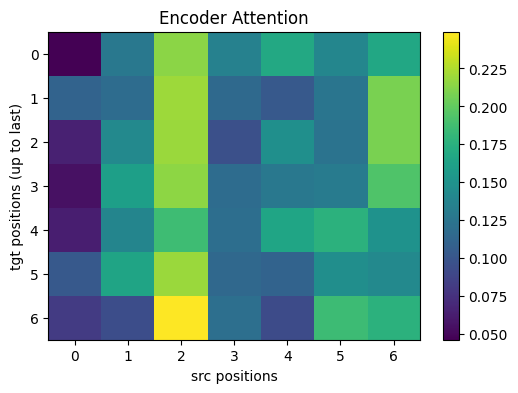

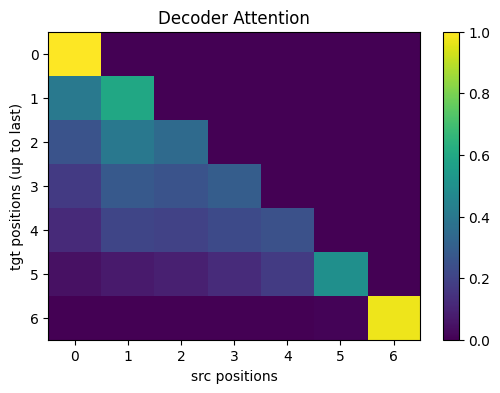

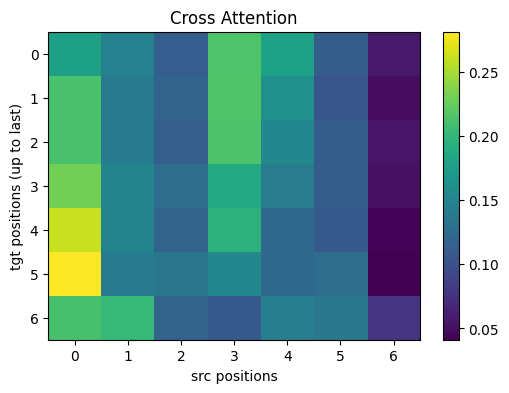

<IPython.core.display.Javascript object>

In [32]:
#inputs, l_last_enc_attn, l_last_dec_attn, l_last_cross_attn = transformer([1111, 78, 2345, 2345, 100, 356, 4444], [1111, 78, 2345, 2345, 100, 356, 1, 4444])

print(len(last_cross_attn))
print(len(last_dec_attn))
print(len(last_enc_attn))

print(last_cross_attn[5].shape)
print(last_dec_attn[5].shape)
print(last_enc_attn[5].shape)

num_keys=1
keys = torch.randint(low=0, high=100, size=(num_keys,1))
keys_low = torch.randint(low=200, high=300, size=(num_keys,1))
keys_hl = torch.randint(low=300, high=400, size=(num_keys,1))

val_src_data_s = torch.randint(1000, src_vocab_size, (1, max_seq_length))
val_tgt_data_s = torch.randint(1000, tgt_vocab_size, (1, max_seq_length))
val_src_data_l = torch.randint(10, 500, (64, max_seq_length))
val_tgt_data_l = torch.randint(10, 500, (64, max_seq_length))

#high low sequence

val_src_data_hi = torch.randint(1000, src_vocab_size, (1, max_seq_length_h))
val_tgt_data_hi = torch.randint(1000, tgt_vocab_size, (1, max_seq_length_h))
val_src_data_lo = torch.randint(10, 500, (1, max_seq_length_h))
val_tgt_data_lo = torch.randint(10, 500, (1, max_seq_length_h))
val_src_data_hl = torch.cat((val_src_data_hi, val_src_data_lo), 1)
val_tgt_data_hl = torch.cat((val_tgt_data_hi, val_tgt_data_lo), 1)

zeros = torch.zeros(size=(num_keys,1), dtype=torch.int64)
ones = torch.ones(size=(num_keys,1), dtype=torch.int64)
fours = torch.full_like(ones, 4) # graph with hi and lows separated.
threes= torch.full_like(ones, 3) # graph with hi and lows separated.
END = torch.full_like(ones, 4444) # Chinese number of great death!
START=torch.full_like(ones, 1111) # start token to check low training accuracy.

val_src_dict = torch.cat((val_src_data_s[:,:0], START, val_src_data_s[:,0:]), dim=1)
val_src_dict = torch.cat((val_src_dict[:,:0], keys, val_src_dict[:,0:]), dim=1)
#val_src_dict = torch.cat((val_src_dict[:,:5], zeros, val_src_data[:,5:]), dim=1)
val_src_dict_sim = torch.cat((val_src_dict[:,:6], END, val_src_dict[:,6:]), dim=1)
print(val_src_dict_sim.shape)
#print(last_enc_attn)
sentence_a=[]
sentence_a.append('1111')
sentence_a.append('78')
sentence_a.append('2345')
sentence_a.append('2345')
sentence_a.append('100')
sentence_a.append('356')
sentence_a.append('4444')
sentence_b = []
sentence_b.append('1111')
sentence_b.append('78')
sentence_b.append('2345')
sentence_b.append('2345')
sentence_b.append('100')
sentence_b.append('356')
sentence_b.append('3')
sentence_b.append('4444')

print(sentence_a)
print(sentence_b)
slice_a = slice(0, sentence_b[0])  # Positions corresponding to sentence A in input
slice_b = slice(sentence_b[0], len(sentence_a))
print(slice_a, slice_b)


# Plot last step's cross-attn
print(len(last_enc_attn)) # 6 layers
print(len(last_enc_attn[5].shape))

last = (last_enc_attn[5][0].detach().cpu())[-1]
plt.figure(figsize=(6,4))
plt.imshow(last, aspect='auto')
plt.xlabel('src positions')
plt.ylabel('tgt positions (up to last)')
plt.title('Encoder Attention')
plt.colorbar()
plt.show()

last = (last_dec_attn[5][0].detach().cpu())[-1]
plt.figure(figsize=(6,4))
plt.imshow(last, aspect='auto')
plt.xlabel('src positions')
plt.ylabel('tgt positions (up to last)')
plt.title('Decoder Attention')
plt.colorbar()
plt.show()

last = (last_cross_attn[5][0].detach().cpu())[-1]
plt.figure(figsize=(6,4))
plt.imshow(last, aspect='auto')
plt.xlabel('src positions')
plt.ylabel('tgt positions (up to last)')
plt.title('Cross Attention')
plt.colorbar()
plt.show()
enc_attention = tuple(last_enc_attn)
dec_attention = tuple(last_dec_attn)
cross_attention = tuple(last_cross_attn)
head_view(enc_attention, sentence_a, sentence_b_start=None)

#model_view(
#    encoder_attention=last_enc_attn,
#    decoder_attention=last_dec_attn,
#    cross_attention=last_dec_attn,
#    encoder_tokens= sentence_a,
#    decoder_tokens = sentence_b
#)
#model_view(last_enc_attn, sentence_a)
#attn_new = []
#for _ in range(len(sentence_a)):
#    attn_new.append(last_enc_attn)


